C:\Users\nitin bansal\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\nitin bansal\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Prediction for 5 hours: Pass (Prob: 0.7156)
Prediction for 10 hours: Pass (Prob: 0.9961)


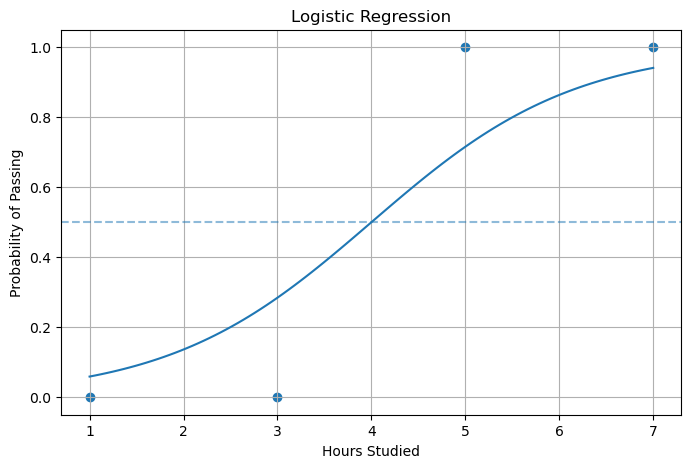

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
data=pd.read_csv("LGR.csv")
data

x=data[['hours']]
y=data[['pass']]

model=LogisticRegression()
model.fit(x,y)

X_new = pd.DataFrame({'hours': [5, 10]})
predictions = model.predict(X_new)
probabilities = model.predict_proba(X_new)[:, 1]
print(f"Prediction for 5 hours: {'Pass' if predictions[0]==1 else 'Fail'} (Prob: {probabilities[0]:.4f})")
print(f"Prediction for 10 hours: {'Pass' if predictions[1]==1 else 'Fail'} (Prob: {probabilities[1]:.4f})")


x_range = np.linspace(x.min(), x.max(), 100).reshape(-1,1)
y_range_prob = model.predict_proba(x_range)[:,1]
plt.figure(figsize=(8,5))
plt.scatter(x, y)
plt.plot(x_range, y_range_prob)
plt.axhline(0.5, linestyle='--', alpha=0.5)

plt.xlabel("Hours Studied")
plt.ylabel("Probability of Passing")
plt.title("Logistic Regression")
plt.grid(True)
plt.show()